# Healthcare Claims Cost Analysis

## Objective
Analzye healthcare data in claims to highlight key cost drivers and based of data-driven evidence provide recommendations to reduce overall healthcare spending while improving patient outcomes and satisfaction.

## Tools
- Python (Pandas, Numpy, matplotlib)
- SQL (PostgreSQL, Bash)
- CSV File

## Main Insights
1. The Top 20% of patients drive most of the spending --> More need of preventive care.
   a. The Top 20% of patients account contribute heavily to the total healthcare spending, developing a right-side skew cost distrubtion. Preventive care focused on the top 20% would greatly impact total healthcare spending.
2. ER visits are the most expense care --> Reduction in cost via urgent care/telehealth.
   b. ER vists are the highest in average cost per visit. By diverting less critical care cases to urgent care or telehealth would reduce visit expenses.
3. Heart disease and diabetes increase cost --> exploration into diease management.
   c. Chronic illnesses, mainly heart disease and diabetes contribute the most to total healthcare cost. Funding disease management programs can improve client outcomes and therefore reduce long-term costs.
4. High-cost providers --> Review and negotiate contracts/or modify utilization.
   d. Some providers have higher costs compared to others, by reviewing contracts and looking at trends can help optimize spending.
5. Seasonal Spikes --> Plan for staffing/resources based on trends.
   e. Healthcare can vary in spending from month-to-month, suggesting seasonal trends, by predicting these trends proper staffing and resource availablity can help reduce cost and increase efficiency.

In [27]:
import pandas as pd
import numpy as np

np.random.seed(42)

#Creating Patients Table

n_patients = 1000

patients =pd.DataFrame({
    "patient_id": range(1, n_patients +1),
    "age": np.random.randint(18, 80, n_patients),
    "gender": np.random.choice(["M", "F"], n_patients),
    "chronic_condition": np.random.choice(
        ["Diabetes", "Hypertension", "Heart Disease", "None"],
        n_patients
    )
})

#Create Providers Table
n_providers = 50

providers = pd.DataFrame({
    "provider_id": range(1, n_providers + 1),
    "provider_type": np.random.choice(
        ["Hospital", "Clinic", "Specialist"],
        n_providers
    )
})

# Create Claims Table

n_claims = 5000

claims = pd.DataFrame({
    "claim_id": range(1, n_claims + 1),
    "patient_id": np.random.choice(patients["patient_id"], n_claims),
    "provider_id": np.random.choice(providers["provider_id"], n_claims),
    "claim_cost": np.round(np.random.exponential(scale=2000, size = n_claims), 2),
    "visit_type": np.random.choice(["ER", "Routine", "Urgent"], n_claims),
    "date": pd.to_datetime("2024-01-01") + pd.to_timedelta(
        np.random.randint(0, 365, n_claims), unit = "d"
    )
})

# Save and Create CSV Files

patients.to_csv("patients_clean.csv", index = False)

providers.to_csv("providers_clean.csv", index = False)

claims.to_csv("claims_clean.csv", index = False)

print("CSV files successfully created and loaded.")
    

CSV files successfully created and loaded.


In [28]:
!pip install psycopg2-binary pandas

In [29]:
import psycopg2
import pandas as pd

#Connecting to PostgreSQL

conn = psycopg2.connect(
    dbname = "healthcare_db",
    user = "postgres",
    password = "Ilovesky2!",
    host = "localhost",
    port = "5432"
)

# Query for the database

df = pd.read_sql("SELECT * FROM patients LIMIT 5;", conn)
print(df)

# Closing the Connection
conn.close()
    

   patient_id  age gender chronic_condition
0           1   56      M     Heart Disease
1           2   69      M          Diabetes
2           3   46      F     Heart Disease
3           4   32      M          Diabetes
4           5   60      M     Heart Disease


In [30]:
# Importing Libraries

import pandas as pd
import psycopg2
import warnings
warnings.filterwarnings('ignore') # Way to remove Pandas warning

# Makes Connection to PostgreSQL Database
conn = psycopg2.connect(
    dbname = "healthcare_db",
    user = "postgres",
    password = "Ilovesky2!",
    host = "localhost",
    port = "5432"
)

In [31]:
#Loading Tables into Pandas for querying and visualization purposes

# Patients Table
df_patients = pd.read_sql("SELECT * FROM patients;", conn)

# Providers Table
df_providers = pd.read_sql("SELECT * FROM providers;", conn)

# Claims Table
df_claims = pd.read_sql("SELECT * FROM claims;", conn)

# Check to make sure everything is loaded
print(df_patients.head())
print(df_providers.head())
print(df_claims.head())


   patient_id  age gender chronic_condition
0           1   56      M     Heart Disease
1           2   69      M          Diabetes
2           3   46      F     Heart Disease
3           4   32      M          Diabetes
4           5   60      M     Heart Disease
   provider_id provider_type
0            1    Specialist
1            2    Specialist
2            3      Hospital
3            4      Hospital
4            5        Clinic
   claim_id  patient_id  provider_id  claim_cost visit_type        date
0         1         726           46     1336.78    Routine  2024-08-14
1         2         220           14      905.49     Urgent  2024-04-21
2         3         905           37     2039.90     Urgent  2024-05-27
3         4          26           18      276.31         ER  2024-09-25
4         5         521           24     1125.35     Urgent  2024-07-21


In [32]:
# Merging Table to Prep for Data Cleaning
merged = df_claims.merge(df_patients, on = 'patient_id').merge(df_providers, on = 'provider_id')

In [33]:
# Data Cleaning

# Matching Correct Data Types
merged['date'] = pd.to_datetime(merged['date'], errors = 'coerce')

merged['claim_cost'] = pd.to_numeric(merged['claim_cost'], errors = 'coerce')

# Identifying Missing Values

merged = merged.dropna(subset = ['patient_id', 'provider_id', 'claim_cost'])

merged['chronic_condition'] = merged['chronic_condition'].fillna('Unknown')

# Deleting Duplicate Rows

merged = merged.drop_duplicates()

#Formatting Columns 

merged['gender'] = merged['gender'].str.capitalize()

merged['visit_type'] = merged['visit_type'].str.upper()

merged['chronic_condition'] = merged['chronic_condition'].str.title()

merged['provider_type'] = merged['provider_type'].str.title()

#Filtering Outliers 

# Detects Top 1% of Outliers
high_cost_threshold = merged['claim_cost'].quantile(0.99)

print("Top 1% claim cost threshold:", high_cost_threshold) 

# Highlights Above Average Claims

merged['month'] = merged['date'].dt.month

merged['year'] = merged['date'].dt.year

merged['high_cost_flag'] = merged['claim_cost'] > merged['claim_cost'].quantile(0.80)

# Total Cost at the Patient-level 

patient_costs = merged.groupby('patient_id')['claim_cost'].sum().reset_index()

# Data after Cleaning

print("Data shape after cleaning:", merged.shape)

print(merged.head())

conn.close()


Top 1% claim cost threshold: 8997.610600000007
Data shape after cleaning: (5000, 13)
   claim_id  patient_id  provider_id  claim_cost visit_type       date  age  \
0         1         726           46     1336.78    ROUTINE 2024-08-14   51   
1         2         220           14      905.49     URGENT 2024-04-21   79   
2         3         905           37     2039.90     URGENT 2024-05-27   61   
3         4          26           18      276.31         ER 2024-09-25   47   
4         5         521           24     1125.35     URGENT 2024-07-21   67   

  gender chronic_condition provider_type  month  year  high_cost_flag  
0      M          Diabetes      Hospital      8  2024           False  
1      F              None    Specialist      4  2024           False  
2      F     Heart Disease        Clinic      5  2024           False  
3      F     Heart Disease        Clinic      9  2024           False  
4      M      Hypertension        Clinic      7  2024           False  


Total Healthcare Spending:$ 9796263.23
chronic_condition
Diabetes         2585244.12
Heart Disease    2497914.80
Hypertension     2362800.86
None             2350303.45
Name: claim_cost, dtype: float64
visit_type
ER         1967.410030
ROUTINE    1963.591904
URGENT     1946.828606
Name: claim_cost, dtype: float64
chronic_condition
Diabetes         5179.385840
Heart Disease    5054.674275
Hypertension     5191.621362
None             5013.206556
Name: claim_cost, dtype: float64
month
1     840390.45
2     884452.89
3     885029.77
4     939953.80
5     888312.53
6     758908.08
7     746424.19
8     793131.95
9     693821.26
10    793235.55
11    766345.71
12    806257.05
Name: claim_cost, dtype: float64
provider_type
Clinic        3517271.95
Specialist    3440102.77
Hospital      2838888.51
Name: claim_cost, dtype: float64


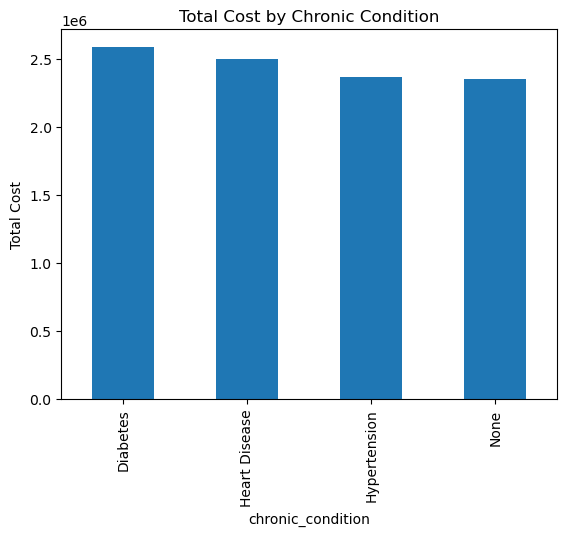

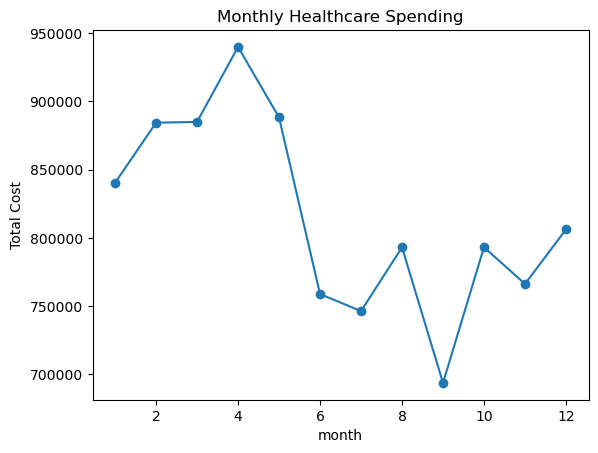

In [34]:
# Main Analysis

#Total Claim Cost

total_cost = merged['claim_cost'].sum()

print("Total Healthcare Spending:$", round(total_cost, 2))

# Cost by Chronic Condition

cost_by_chronic_condition = merged.groupby('chronic_condition')['claim_cost'].sum().sort_values(ascending = False)

print(cost_by_chronic_condition)

# Cost for Vist Type

cost_for_visit = merged.groupby('visit_type')['claim_cost'].mean().sort_values(ascending = False)

print(cost_for_visit)

# Top Costing Patients

threshold = merged['claim_cost'].quantile(0.80)

high_cost_patients = merged[merged['claim_cost'] > threshold]

# Grouping Chronic Conditions

high_cost_by_chronic_condition = high_cost_patients.groupby('chronic_condition')['claim_cost'].mean()

print(high_cost_by_chronic_condition)

# Monthly Trends

monthly_cost = merged.groupby('month')['claim_cost'].sum()

print(monthly_cost)

# Analysis of Provider 
cost_by_provider = merged.groupby('provider_type')['claim_cost'].sum().sort_values(ascending = False)

print(cost_by_provider)

# Small Visualization

#importing from python libary 

import matplotlib.pyplot as plt

# Cost for Condition

cost_by_chronic_condition.plot(kind = 'bar', title = 'Total Cost by Chronic Condition')

plt.ylabel('Total Cost')

plt.show()

# Monthly Trends

monthly_cost.plot(kind = 'line', title = 'Monthly Healthcare Spending', marker = 'o')

plt.ylabel('Total Cost')

plt.show()

      

In [35]:
# Saving Results and Visualizations

# Saving Main Data Analysis

cost_by_chronic_condition.to_csv('cost_by_condition.csv')

monthly_cost.to_csv('monthly_cost.csv')

high_cost_by_chronic_condition.to_csv('high_cost_by_chronic_condition.csv')

# Saving Visualizations

plt.figure()

cost_by_chronic_condition.plot(kind = 'bar', title = 'Total Cost By Chronic Condition')

plt.ylabel('Total Cost')

plt.savefig('cost_by_chronic_condition_chart.png')

plt.close()

#Figure 2

plt.figure()

monthly_cost.plot(kind = 'line', title = 'Monthly Healthcare Spending', marker = 'o')

plt.ylabel('Total Cost')

plt.savefig('monthly_trends_chart.png')

plt.close()
